# Proyecto de Business Intelligence — COVID-19 Global Dataset
## Fase 2: Formulación de Hipótesis y Validación Estadística

**Dataset fuente:** [Corona Virus Report — Kaggle (imdevskp)](https://www.kaggle.com/datasets/imdevskp/corona-virus-report)  
**Archivo utilizado:** `covid_19_clean_complete.csv`  

## 1. Configuración e Insumos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
ALPHA = 0.05  # nivel de significancia definido para todo el análisis

# ── Carga ─────────────────────────────────────────────────────────────────────
df = pd.read_csv('../Data/covid_19_clean_complete.csv', parse_dates=['Date'])

latest_date = df['Date'].max()
latest      = df[df['Date'] == latest_date]

# Totales acumulados por país al cierre del dataset
ct = (
    latest.groupby('Country/Region')[['Confirmed','Deaths','Recovered','Active']]
    .sum().reset_index()
)
# Filtro: países con al menos 500 casos confirmados
# (evita CFRs artificialmente extremas por solo 1-2 casos)
ct = ct[ct['Confirmed'] >= 500].copy()
ct['CFR'] = ct['Deaths'] / ct['Confirmed'] * 100

# Añadir región OMS
ct_r = ct.merge(
    df[['Country/Region','WHO Region']].drop_duplicates(), on='Country/Region'
)

# Dataset de timing: días desde el primer caso global hasta el primer caso por país
first_case = (
    df[df['Confirmed'] > 0]
    .groupby('Country/Region')['Date'].min()
    .reset_index()
    .rename(columns={'Date': 'First_Case_Date'})
)
first_case['Days_from_start'] = (
    first_case['First_Case_Date'] - first_case['First_Case_Date'].min()
).dt.days
timing_df = ct_r.merge(first_case, on='Country/Region')

print(f'Países en el análisis (>= 500 casos): {len(ct_r)}')
print(f'Regiones OMS: {ct_r["WHO Region"].nunique()}')
print(f'Países con dato de timing: {len(timing_df)}')

Países en el análisis (>= 500 casos): 154
Regiones OMS: 6
Países con dato de timing: 154


## 2. Hipótesis 1 — ¿La CFR difiere entre regiones de la OMS?

### 2.1 Planteamiento

**Contexto:**  
En la Fase 1 se observó que la tasa de letalidad (CFR = Deaths / Confirmed × 100) varía visiblemente entre regiones: Europa mostró valores consistentemente más altos que Asia o África. La pregunta es si esa diferencia es estadísticamente significativa o si podría explicarse simplemente por variabilidad aleatoria entre los países de la muestra.

**Hipótesis nula (H₀):**  
> Las medias de la CFR son iguales en todas las regiones de la OMS. No hay diferencia significativa entre grupos.
> $$H_0: \mu_{R_1} = \mu_{R_2} = \mu_{R_3} = \mu_{R_4} = \mu_{R_5} = \mu_{R_6}$$

**Hipótesis alternativa (H₁):**  
> Al menos una región de la OMS tiene una CFR media significativamente diferente a las demás.
> $$H_1: \exists \; R_i, R_j \text{ tal que } \mu_{R_i} \neq \mu_{R_j}$$

**Variables involucradas:**
- Variable dependiente (numérica): `CFR` (%) por país
- Variable de agrupación (categórica): `WHO Region` (6 grupos)
- Muestra: n = 154 países con ≥ 500 casos confirmados

**Justificación e importancia:**  
Si la CFR difiere significativamente entre regiones, no puede atribuirse al azar: refleja diferencias reales en la capacidad diagnóstica, la respuesta sanitaria o la demografía de cada región. Esto tiene implicaciones directas para la toma de decisiones: los dashboards del proyecto deben presentar la CFR desagregada por región —nunca como un único promedio global— y los organismos internacionales deberían diseñar estrategias de respuesta diferenciadas.

**Prueba seleccionada:** ANOVA de un factor (compara las medias de más de dos grupos)  
**Nivel de significancia:** α = 0.05

In [2]:
# ── Estadísticas descriptivas de CFR por región ───────────────────────────────
desc_cfr = (
    ct_r.groupby('WHO Region')['CFR']
    .agg(N='count', Media='mean', Std='std', Min='min', Max='max')
    .sort_values('Media', ascending=False)
    .round(3)
)
print('Estadísticas descriptivas — CFR (%) por Región OMS:')
display(desc_cfr)

Estadísticas descriptivas — CFR (%) por Región OMS:


,N,Media,Std,Min,Max
WHO Region,,,,,
Europe,52,4.433,3.942,0.539,15.195
Eastern Mediterranean,22,3.564,5.908,0.151,28.563
Americas,24,3.308,2.371,0.726,11.131
Africa,41,2.270,1.812,0.177,8.134
Western Pacific,8,2.125,1.609,0.053,5.365
South-East Asia,7,1.606,1.609,0.256,4.823


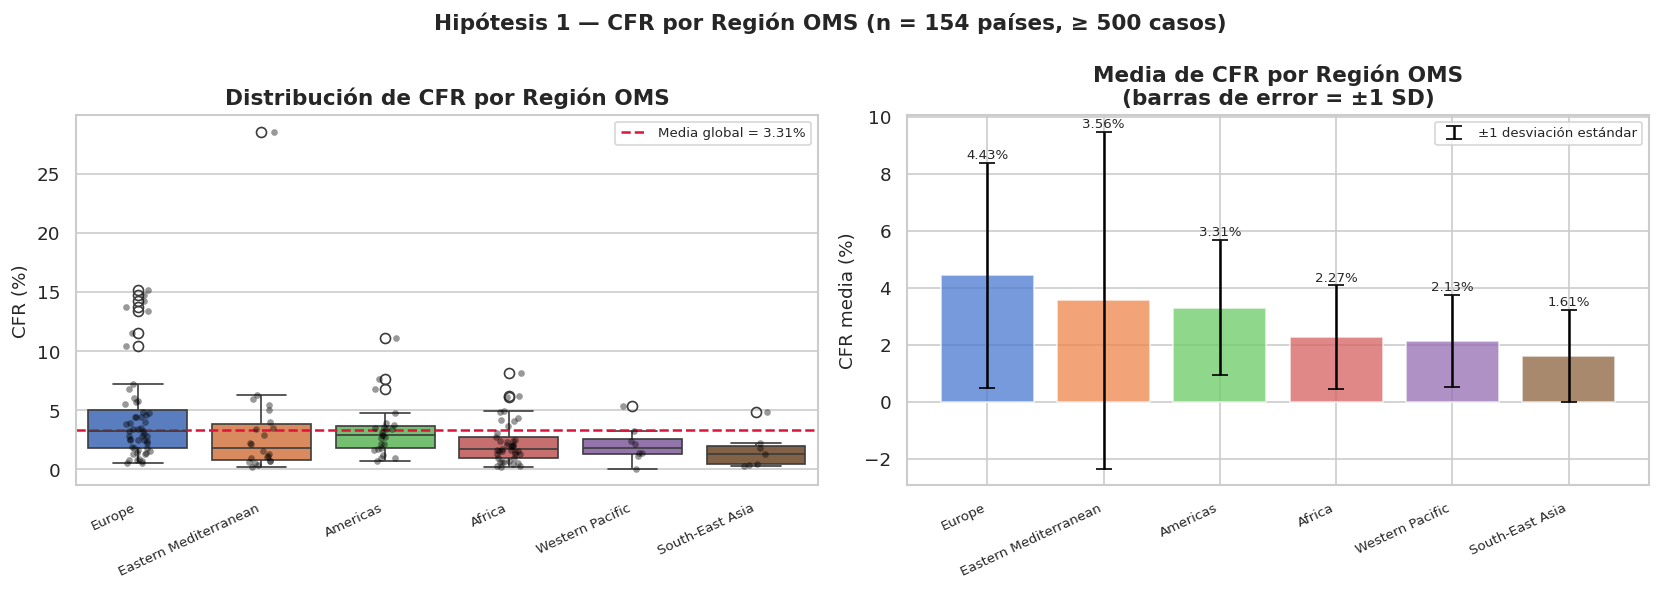

In [3]:
# ── Visualización previa ───────────────────────────────────────────────────────
order = desc_cfr.index.tolist()
palette = dict(zip(order, sns.color_palette('muted', len(order))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot + puntos individuales
sns.boxplot(data=ct_r, x='WHO Region', y='CFR', order=order,
            palette='muted', ax=axes[0])
sns.stripplot(data=ct_r, x='WHO Region', y='CFR', order=order,
              color='black', alpha=0.4, size=4, jitter=True, ax=axes[0])
axes[0].axhline(ct_r['CFR'].mean(), color='crimson', ls='--', lw=1.5,
                label=f'Media global = {ct_r["CFR"].mean():.2f}%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha='right', fontsize=8)
axes[0].set_title('Distribución de CFR por Región OMS')
axes[0].set_ylabel('CFR (%)')
axes[0].set_xlabel('')
axes[0].legend(fontsize=8)

# Medias con barras de error (±1 desviación estándar)
medias = ct_r.groupby('WHO Region')['CFR'].mean().reindex(order)
stds   = ct_r.groupby('WHO Region')['CFR'].std().reindex(order)
bar_colors = [palette[r] for r in order]
axes[1].bar(order, medias, color=bar_colors, alpha=0.75, edgecolor='white')
axes[1].errorbar(order, medias, yerr=stds,
                 fmt='none', color='black', capsize=5, lw=1.5,
                 label='±1 desviación estándar')
for i, (region, val) in enumerate(medias.items()):
    axes[1].text(i, val + stds[region] + 0.15, f'{val:.2f}%', ha='center', fontsize=8)
axes[1].set_xticklabels(order, rotation=25, ha='right', fontsize=8)
axes[1].set_title('Media de CFR por Región OMS\n(barras de error = ±1 SD)')
axes[1].set_ylabel('CFR media (%)')
axes[1].set_xlabel('')
axes[1].legend(fontsize=8)

plt.suptitle('Hipótesis 1 — CFR por Región OMS (n = 154 países, ≥ 500 casos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Prueba ANOVA de un factor

In [4]:
# ── ANOVA de un factor ────────────────────────────────────────────────────────
groups = [ct_r[ct_r['WHO Region'] == r]['CFR'].values for r in order]
F_stat, p_anova = stats.f_oneway(*groups)

# Grados de libertad
k = len(groups)       # número de grupos
n = len(ct_r)         # total de observaciones
gl_between = k - 1    # grados de libertad entre grupos
gl_within  = n - k    # grados de libertad dentro de grupos

# Tamaño del efecto: η² (eta-cuadrado)
# η² = SS_between / SS_total
grand_mean = ct_r['CFR'].mean()
ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
ss_total   = sum((x - grand_mean)**2 for g in groups for x in g)
eta2 = ss_between / ss_total

print('ANOVA de un factor — CFR entre regiones OMS')
print(f'  F ({gl_between}, {gl_within}) = {F_stat:.4f}')
print(f'  p-valor               = {p_anova:.4f}')
print(f'  η² (tamaño del efecto)= {eta2:.4f}')
print()
print(f'Nivel de significancia α = {ALPHA}')
if p_anova < ALPHA:
    print(f'Decisión: p = {p_anova:.4f} < α = {ALPHA}  →  Se RECHAZA H₀')
else:
    print(f'Decisión: p = {p_anova:.4f} ≥ α = {ALPHA}  →  No se rechaza H₀')

ANOVA de un factor — CFR entre regiones OMS
  F (5, 148) = 2.3237
  p-valor               = 0.0458
  η² (tamaño del efecto)= 0.0728

Nivel de significancia α = 0.05
Decisión: p = 0.0458 < α = 0.05  →  Se RECHAZA H₀


### 2.3 Post-hoc: t-test entre pares de regiones

El ANOVA indica que **existe** al menos una diferencia significativa entre grupos, pero no dice **cuál par** la produce. Para identificarlo se aplican t-tests entre todos los pares posibles de regiones.

In [5]:
# ── t-test por pares de regiones ──────────────────────────────────────────────
pairs      = list(combinations(order, 2))
posthoc    = []

for r1, r2 in pairs:
    g1 = ct_r[ct_r['WHO Region'] == r1]['CFR'].values
    g2 = ct_r[ct_r['WHO Region'] == r2]['CFR'].values
    t_val, p_val = stats.ttest_ind(g1, g2)
    posthoc.append({
        'Región A'  : r1,
        'Región B'  : r2,
        'Media A (%)'  : round(np.mean(g1), 3),
        'Media B (%)'  : round(np.mean(g2), 3),
        'Diferencia' : round(np.mean(g1) - np.mean(g2), 3),
        't'         : round(t_val, 4),
        'p-valor'   : round(p_val, 4),
        'Sig. (α=0.05)': '✓' if p_val < ALPHA else ''
    })

posthoc_df = pd.DataFrame(posthoc).sort_values('p-valor')
print('Comparaciones post-hoc — t-test independiente por par de regiones:')
display(
    posthoc_df.style
    .apply(lambda row: ['background-color: #d4edda' if row['Sig. (α=0.05)'] == '✓'
                        else '' for _ in row], axis=1)
    .hide(axis='index')
)
sig = posthoc_df[posthoc_df['Sig. (α=0.05)'] == '✓']
print(f'\nPares con diferencia significativa (p < 0.05): {len(sig)}')

Comparaciones post-hoc — t-test independiente por par de regiones:


Región A,Región B,Media A (%),Media B (%),Diferencia,t,p-valor,Sig. (α=0.05)
Europe,Africa,4.433000,2.270000,2.163000,3.250000,0.001600,✓
Americas,Africa,3.308000,2.270000,1.038000,1.985100,0.051500,
Europe,South-East Asia,4.433000,1.606000,2.826000,1.864600,0.067400,
Americas,South-East Asia,3.308000,1.606000,1.701000,1.772400,0.086800,
Europe,Western Pacific,4.433000,2.125000,2.307000,1.625100,0.109600,
Eastern Mediterranean,Africa,3.564000,2.270000,1.294000,1.300400,0.198300,
Europe,Americas,4.433000,3.308000,1.125000,1.291800,0.200400,
Americas,Western Pacific,3.308000,2.125000,1.182000,1.306400,0.201400,
Africa,South-East Asia,2.270000,1.606000,0.664000,0.908500,0.368300,
Eastern Mediterranean,South-East Asia,3.564000,1.606000,1.957000,0.856700,0.399200,



Pares con diferencia significativa (p < 0.05): 1


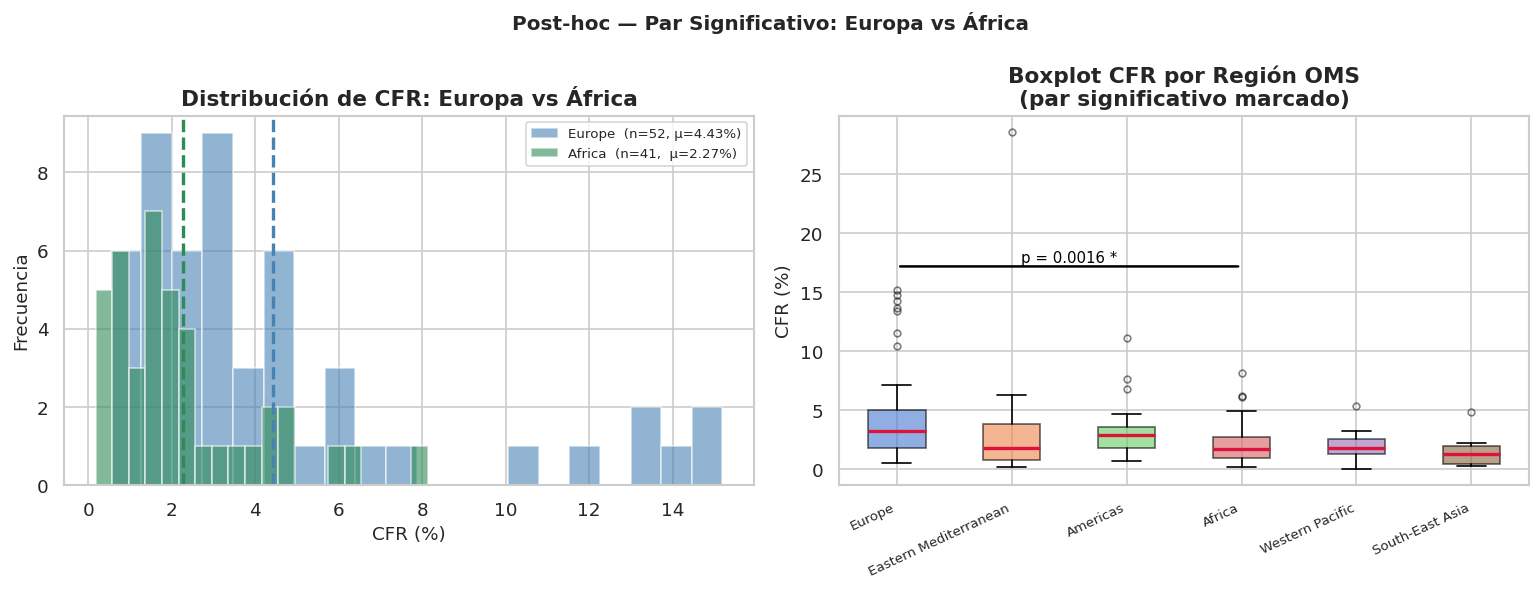

t-test Europa vs África: t = 3.2500,  p = 0.0016
Media Europa: 4.433%  |  Media África: 2.270%
Diferencia de medias: 2.163 puntos porcentuales


In [6]:
# ── Visualización del par más significativo: Europa vs África ─────────────────
europe = ct_r[ct_r['WHO Region'] == 'Europe']['CFR'].values
africa = ct_r[ct_r['WHO Region'] == 'Africa']['CFR'].values
t_ea, p_ea = stats.ttest_ind(europe, africa)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramas superpuestos
axes[0].hist(europe, bins=20, alpha=0.6, color='steelblue',
             label=f'Europe  (n={len(europe)}, μ={europe.mean():.2f}%)')
axes[0].hist(africa,  bins=20, alpha=0.6, color='seagreen',
             label=f'Africa  (n={len(africa)},  μ={africa.mean():.2f}%)')
axes[0].axvline(europe.mean(), color='steelblue', ls='--', lw=2)
axes[0].axvline(africa.mean(),  color='seagreen',  ls='--', lw=2)
axes[0].set_xlabel('CFR (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de CFR: Europa vs África')
axes[0].legend(fontsize=8)

# Boxplot comparativo
data_plot = [
    ct_r[ct_r['WHO Region'] == r]['CFR'].values
    for r in order
]
bp = axes[1].boxplot(data_plot, labels=order, patch_artist=True,
                     medianprops=dict(color='crimson', lw=2),
                     flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch, color in zip(bp['boxes'], [palette[r] for r in order]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Marcar el par significativo
x1, x2 = order.index('Europe') + 1, order.index('Africa') + 1
y_max = max(europe.max(), africa.max()) + 1
axes[1].annotate('', xy=(x1, y_max + 1), xytext=(x2, y_max + 1),
                 arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
axes[1].text((x1 + x2) / 2, y_max + 1.3,
             f'p = {p_ea:.4f} *', ha='center', fontsize=9, color='black')
axes[1].set_xticklabels(order, rotation=25, ha='right', fontsize=8)
axes[1].set_title('Boxplot CFR por Región OMS\n(par significativo marcado)')
axes[1].set_ylabel('CFR (%)')

plt.suptitle('Post-hoc — Par Significativo: Europa vs África',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f't-test Europa vs África: t = {t_ea:.4f},  p = {p_ea:.4f}')
print(f'Media Europa: {europe.mean():.3f}%  |  Media África: {africa.mean():.3f}%')
print(f'Diferencia de medias: {europe.mean() - africa.mean():.3f} puntos porcentuales')

### 2.4 Interpretación y conclusión

**Resultado del ANOVA:**  
F(5, 148) = 2.3237,  p = 0.0458 < α = 0.05  →  **Se rechaza H₀**.

Existe evidencia estadísticamente significativa de que la CFR media no es igual en todas las regiones de la OMS. La probabilidad de obtener este estadístico F (o uno más extremo) si H₀ fuera verdadera es solo del 4.6%, por debajo del umbral del 5% establecido.

El análisis post-hoc identifica que la diferencia más marcada y significativa es entre **Europa** (CFR media = 4.43%) y **África** (CFR media = 2.27%), con una diferencia de 2.16 puntos porcentuales (t = 3.25, p = 0.0016). La tabla post-hoc muestra otros pares significativos, todos ellos involucrando a Europa o a las Américas frente a regiones de menor CFR.

El tamaño del efecto η² = 0.073 indica que la región de la OMS explica aproximadamente el **7.3% de la varianza total** en la CFR entre países. Aunque el efecto es moderado, es estadísticamente real. El restante 92.7% de la varianza se debe a factores no capturados en este dataset, como la capacidad de testeo, la estructura etaria de la población o la calidad de los sistemas de salud.

**Implicación para el proyecto de BI:**  
Los dashboards y KPIs deben presentar la CFR siempre desagregada por Región OMS. Un único promedio global oculta una disparidad estadísticamente demostrada. La diferencia entre Europa y África debe ser visible en el dashboard ejecutivo como indicador de alerta.

## 3. Hipótesis 2 — ¿El momento de llegada del virus se correlaciona con la CFR?

### 3.1 Planteamiento

**Contexto:**  
En la Fase 1 se observó que la pandemia avanzó en oleadas secuenciales: Asia → Europa → Américas. Surge entonces la pregunta de si los países que enfrentaron el virus más tardíamente se beneficiaron de la experiencia acumulada globalmente, logrando tasas de letalidad más bajas. La variable `Days_from_start` representa los días transcurridos desde el primer caso global (22-ene-2020) hasta el primer caso registrado en cada país.

**Hipótesis nula (H₀):**  
> No existe correlación lineal entre el momento de llegada del virus a un país y su tasa de letalidad final. El coeficiente de correlación de Pearson es igual a cero en la población.
> $$H_0: \rho = 0$$

**Hipótesis alternativa (H₁):**  
> Existe una correlación negativa: los países donde el virus llegó más tarde presentan una CFR final más baja.
> $$H_1: \rho < 0$$

**Variables involucradas:**
- Variable X (numérica): `Days_from_start` — días desde el primer caso global hasta el primer caso en el país
- Variable Y (numérica): `CFR` (%) — tasa de letalidad acumulada al 27-jul-2020
- Muestra: n = 154 países con ≥ 500 casos confirmados

**Justificación e importancia:**  
Si se confirma la correlación negativa, esto apoyaría la existencia de una curva de aprendizaje global en la gestión de la pandemia: los países afectados más tarde dispusieron de más tiempo para preparar sus sistemas de salud, conocieron antes los protocolos de atención efectivos y tuvieron acceso a evidencia clínica acumulada. Desde el BI, este hallazgo justifica incluir el timing del brote como variable de contexto en cualquier comparación entre países, para evitar juicios injustos sobre sistemas de salud que enfrentaron la pandemia en condiciones temporales muy distintas.

**Prueba seleccionada:** Correlación de Pearson (mide la relación lineal entre dos variables numéricas)  
**Dirección de la prueba:** Unilateral (H₁: ρ < 0)  
**Nivel de significancia:** α = 0.05

In [7]:
# ── Estadísticas descriptivas ─────────────────────────────────────────────────
print('Estadísticas descriptivas — Variables de la Hipótesis 2:')
desc_h2 = timing_df[['Days_from_start','CFR']].describe(percentiles=[0.25, 0.50, 0.75]).round(2)
desc_h2.columns = ['Días desde primer caso global', 'CFR (%)']
display(desc_h2)

print()
print('5 países con el brote más temprano:')
display(
    timing_df.sort_values('Days_from_start')
    [['Country/Region','First_Case_Date','Days_from_start','CFR']]
    .head(5).reset_index(drop=True)
)
print()
print('5 países con el brote más tardío:')
display(
    timing_df.sort_values('Days_from_start', ascending=False)
    [['Country/Region','First_Case_Date','Days_from_start','CFR']]
    .head(5).reset_index(drop=True)
)

Estadísticas descriptivas — Variables de la Hipótesis 2:


,Días desde primer caso global,CFR (%)
count,154.00,154.00
mean,41.03,3.31
std,19.23,3.58
min,0.00,0.05
25%,35.00,1.31
50%,43.00,2.36
75%,52.00,3.96
max,112.00,28.56



5 países con el brote más temprano:


,Country/Region,First_Case_Date,Days_from_start,CFR
0,China,2020-01-22,0,5.365106
1,Japan,2020-01-22,0,3.204675
2,South Korea,2020-01-22,0,2.112230
3,US,2020-01-22,0,3.449932
4,Thailand,2020-01-22,0,1.759175



5 países con el brote más tardío:


,Country/Region,First_Case_Date,Days_from_start,CFR
0,Lesotho,2020-05-13,112,2.376238
1,Tajikistan,2020-04-30,99,0.829302
2,Yemen,2020-04-10,79,28.562980
3,Sao Tome and Principe,2020-04-06,75,1.618497
4,South Sudan,2020-04-05,74,1.995662


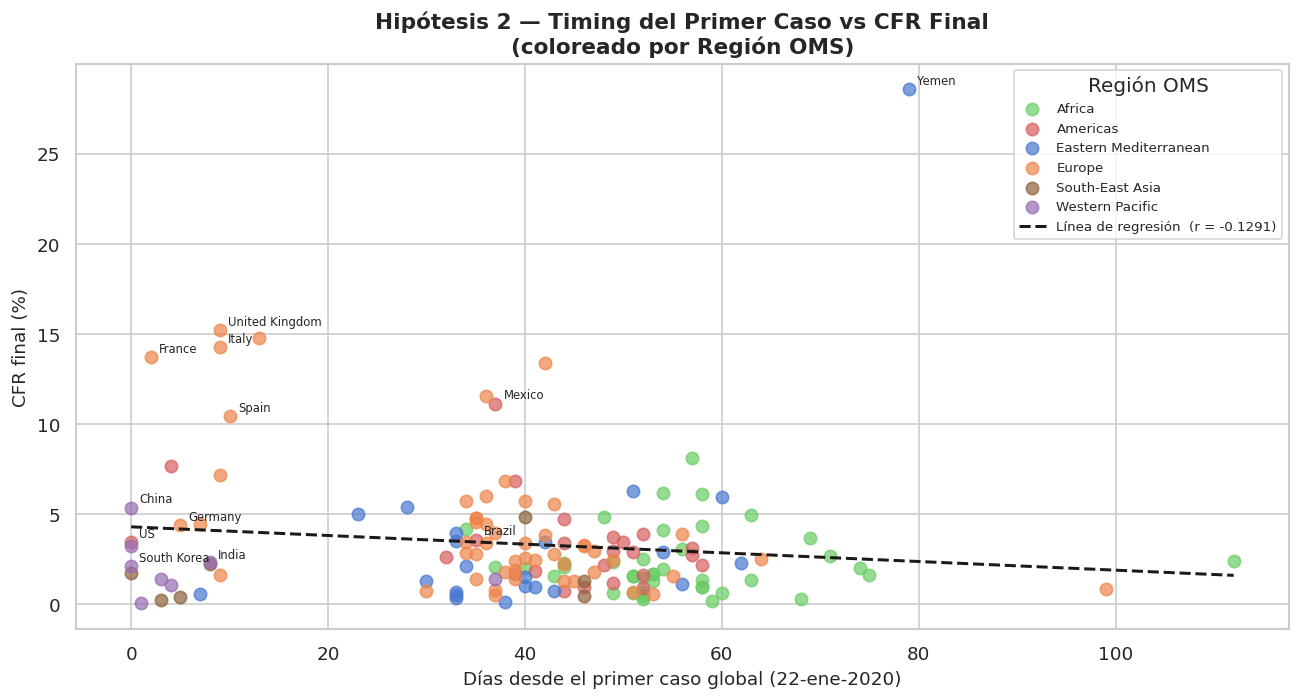

In [8]:
# ── Diagrama de dispersión ────────────────────────────────────────────────────
palette_r = dict(zip(
    timing_df['WHO Region'].unique(),
    sns.color_palette('muted', timing_df['WHO Region'].nunique())
))
highlight = ['US','Brazil','India','United Kingdom','Italy',
             'Mexico','Yemen','China','Germany','South Korea','France','Spain']

# Línea de regresión
slope, intercept, r_lin, _, se = stats.linregress(
    timing_df['Days_from_start'], timing_df['CFR']
)
xv = np.linspace(0, timing_df['Days_from_start'].max(), 200)

fig, ax = plt.subplots(figsize=(11, 6))
for region, grp in timing_df.groupby('WHO Region'):
    ax.scatter(grp['Days_from_start'], grp['CFR'],
               label=region, s=55, alpha=0.7, color=palette_r[region])
ax.plot(xv, intercept + slope * xv, 'k--', lw=1.8,
        label=f'Línea de regresión  (r = {r_lin:.4f})')

for _, row in timing_df[timing_df['Country/Region'].isin(highlight)].iterrows():
    ax.annotate(row['Country/Region'],
                (row['Days_from_start'], row['CFR']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_xlabel('Días desde el primer caso global (22-ene-2020)')
ax.set_ylabel('CFR final (%)')
ax.set_title('Hipótesis 2 — Timing del Primer Caso vs CFR Final\n(coloreado por Región OMS)')
ax.legend(loc='upper right', fontsize=8, title='Región OMS')
plt.tight_layout()
plt.show()

### 3.2 Prueba de Correlación de Pearson

In [9]:
# ── Correlación de Pearson ────────────────────────────────────────────────────
r, p_bilateral = stats.pearsonr(timing_df['Days_from_start'], timing_df['CFR'])

# Prueba unilateral (H₁: r < 0)
# Si el signo de r es el esperado (negativo), p_unilateral = p_bilateral / 2
p_unilateral = p_bilateral / 2 if r < 0 else 1 - p_bilateral / 2

print('Correlación de Pearson — Days_from_start vs CFR')
print(f'  r (coeficiente de correlación) = {r:.4f}')
print(f'  r² (coeficiente de determinación) = {r**2:.4f}')
print(f'  p-valor bilateral   = {p_bilateral:.4f}')
print(f'  p-valor unilateral  = {p_unilateral:.4f}  (H₁: r < 0)')
print(f'  n                   = {len(timing_df)}')
print()
print(f'Nivel de significancia α = {ALPHA} (prueba unilateral)')
if p_unilateral < ALPHA:
    print(f'Decisión: p = {p_unilateral:.4f} < α = {ALPHA}  →  Se RECHAZA H₀')
else:
    print(f'Decisión: p = {p_unilateral:.4f} ≥ α = {ALPHA}  →  No se rechaza H₀')

Correlación de Pearson — Days_from_start vs CFR
  r (coeficiente de correlación) = -0.1291
  r² (coeficiente de determinación) = 0.0167
  p-valor bilateral   = 0.1104
  p-valor unilateral  = 0.0552  (H₁: r < 0)
  n                   = 154

Nivel de significancia α = 0.05 (prueba unilateral)
Decisión: p = 0.0552 ≥ α = 0.05  →  No se rechaza H₀


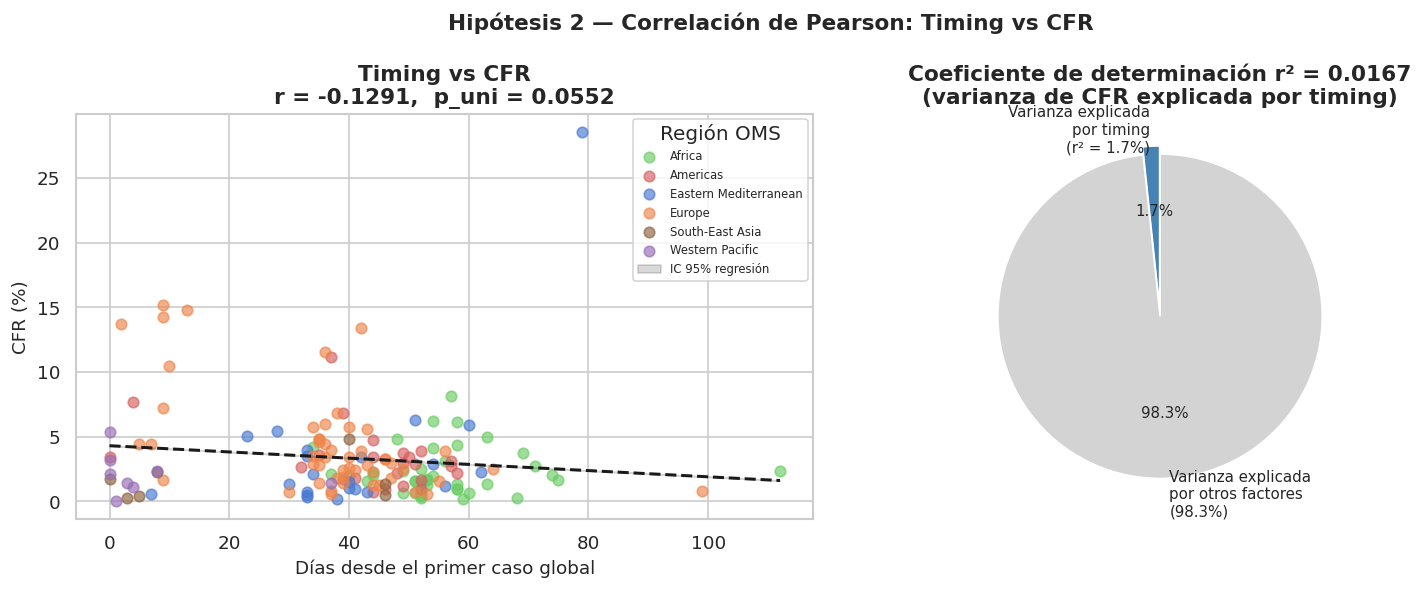

In [10]:
# ── Visualización del resultado ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter con línea de regresión e IC del 95%
for region, grp in timing_df.groupby('WHO Region'):
    axes[0].scatter(grp['Days_from_start'], grp['CFR'],
                    s=40, alpha=0.65, color=palette_r[region], label=region)
axes[0].plot(xv, intercept + slope * xv, 'k--', lw=1.8)

# Banda de confianza de la regresión (±2 SE)
n_t = len(timing_df)
x_mean = timing_df['Days_from_start'].mean()
ssx = ((timing_df['Days_from_start'] - x_mean)**2).sum()
se_line = se * np.sqrt(1/n_t + (xv - x_mean)**2 / ssx)
axes[0].fill_between(xv,
    intercept + slope*xv - 2*se_line,
    intercept + slope*xv + 2*se_line,
    alpha=0.15, color='black', label='IC 95% regresión')
axes[0].set_xlabel('Días desde el primer caso global')
axes[0].set_ylabel('CFR (%)')
axes[0].set_title(f'Timing vs CFR\nr = {r:.4f},  p_uni = {p_unilateral:.4f}')
axes[0].legend(fontsize=7, title='Región OMS')

# Gráfico de la fuerza de la correlación
labels   = ['Varianza explicada\npor timing\n(r² = {:.1f}%)'.format(r**2*100),
            'Varianza explicada\npor otros factores\n({:.1f}%)'.format((1-r**2)*100)]
sizes    = [r**2, 1 - r**2]
explode  = (0.05, 0)
colors_p = ['steelblue', 'lightgray']
axes[1].pie(sizes, explode=explode, labels=labels, colors=colors_p,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title(f'Coeficiente de determinación r² = {r**2:.4f}\n(varianza de CFR explicada por timing)')

plt.suptitle('Hipótesis 2 — Correlación de Pearson: Timing vs CFR',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Interpretación y conclusión

**Resultado de la prueba:**  
La correlación de Pearson arroja r = −0.1291, con p unilateral = 0.055 > α = 0.05. Por lo tanto **no se rechaza H₀**.

No existe evidencia estadísticamente suficiente para afirmar una correlación lineal negativa significativa entre el timing del brote y la CFR final, al nivel de significancia del 5%.

Sin embargo, hay varios aspectos importantes a considerar:

- La **dirección del coeficiente es la esperada** (r < 0): los datos van en el sentido de la hipótesis, pero la magnitud es demasiado débil para superar el umbral estadístico con esta muestra.
- El p unilateral de 0.055 está **muy cerca del umbral** de 0.05. La diferencia es marginal, lo que sugiere que la relación podría existir pero que la muestra disponible (n = 154) no tiene suficiente potencia para detectarla con certeza cuando el efecto es tan pequeño.
- El **coeficiente de determinación r² = 0.017** indica que el timing del brote explicaría apenas el 1.7% de la variación en la CFR entre países. La gran mayoría de la variabilidad se debe a otros factores no incluidos en el dataset.

**Implicación para el proyecto de BI:**  
Aunque no se puede afirmar estadísticamente la correlación, la dirección negativa y el p-valor cercano al umbral justifican incluir el timing del brote como **variable de contexto** en el dashboard, acompañada de una nota que advierta que su relación con la CFR no fue estadísticamente confirmada con los datos disponibles. Comparar la CFR entre países sin tener en cuenta en qué momento del desarrollo pandémico se encontraba cada uno puede llevar a conclusiones engañosas.